# Autonomous Taxi RL Agent – Q-Learning with Visualizations
Training process of the RL agent, extended with learning curves, an epsilon-decay plot, Q-value/policy heatmaps and a multi-episode evaluation.

In [1]:
import gymnasium as gym
import numpy as np
import random
import time
import os
import matplotlib.pyplot as plt

# 1. Initialize the Environment (no render mode for fast training)
env = gym.make("Taxi-v4")

# 2. Initialize the Q-Table: 500 states x 6 actions
state_size = env.observation_space.n
action_size = env.action_space.n
q_table = np.zeros((state_size, action_size))

# 3. Hyperparameters
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.001
min_epsilon = 0.01
episodes = 10000

# Logging for visualizations
episode_rewards = []
episode_steps = []
epsilon_history = []

print("Training the agent... (This will take a few seconds)")

# 4. Training Loop
for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done:
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state, :])

        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated   # also stop on time-limit truncation

        old_value = q_table[state, action]
        next_max = np.max(q_table[new_state, :])
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        state = new_state
        total_reward += reward
        steps += 1

    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    epsilon_history.append(epsilon)
    epsilon = max(min_epsilon, epsilon - epsilon_decay)

print("Training complete!")
env.close()

Training the agent... (This will take a few seconds)


Training complete!


## 1. Learning curve – reward per episode
The raw reward is noisy, so a 100-episode moving average is overlaid. Rewards start very negative (random driving, illegal pickups/drop-offs) and rise towards a stable positive reward (about +8 on average; short trips score higher).

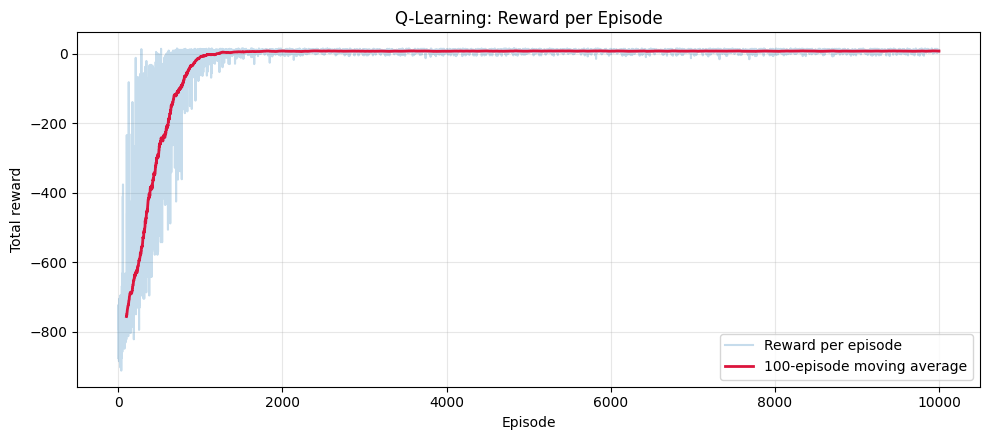

In [2]:
def moving_avg(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(10, 4.5))
plt.plot(episode_rewards, alpha=0.25, label="Reward per episode")
plt.plot(np.arange(99, episodes), moving_avg(episode_rewards), color="crimson", lw=2, label="100-episode moving average")
plt.xlabel("Episode"); plt.ylabel("Total reward")
plt.title("Q-Learning: Reward per Episode")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Steps per episode
Fewer steps means the agent finds shorter routes. The curve should fall quickly and then flatten at a small number.

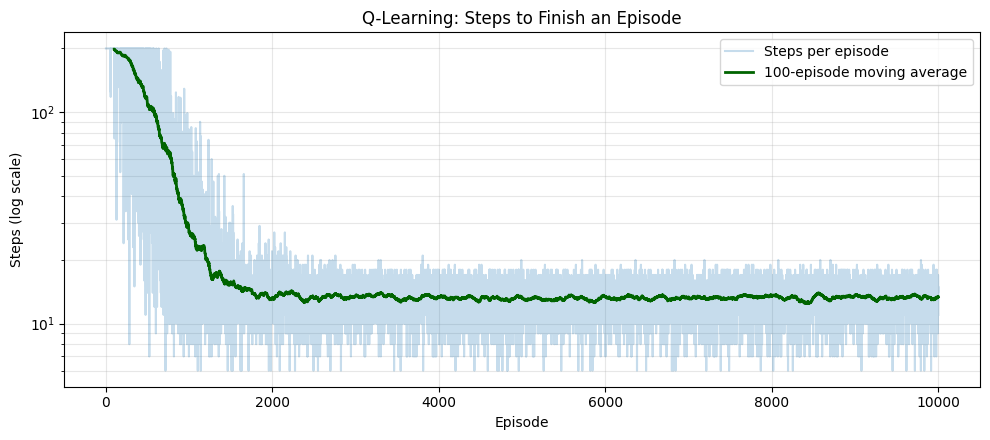

In [3]:
plt.figure(figsize=(10, 4.5))
plt.plot(episode_steps, alpha=0.25, label="Steps per episode")
plt.plot(np.arange(99, episodes), moving_avg(episode_steps), color="darkgreen", lw=2, label="100-episode moving average")
plt.yscale("log")
plt.xlabel("Episode"); plt.ylabel("Steps (log scale)")
plt.title("Q-Learning: Steps to Finish an Episode")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 3. Epsilon decay (exploration vs exploitation)
With a linear decay of 0.001 per episode, epsilon hits its floor of 0.01 after roughly 990 episodes.

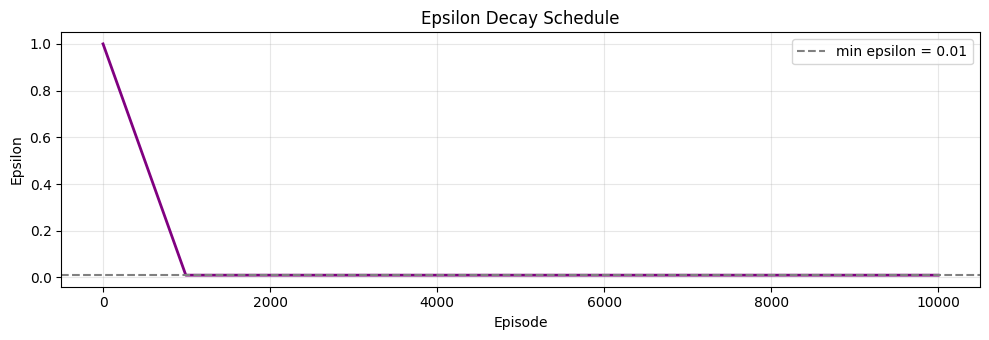

In [4]:
plt.figure(figsize=(10, 3.5))
plt.plot(epsilon_history, color="purple", lw=2)
plt.axhline(min_epsilon, color="gray", ls="--", label=f"min epsilon = {min_epsilon}")
plt.xlabel("Episode"); plt.ylabel("Epsilon")
plt.title("Epsilon Decay Schedule")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Learned values and policy as heatmaps
For a fixed passenger location and destination, each cell shows the best Q-value for the taxi at that grid position; arrows show the greedy action (P = pickup, D = dropoff). Left: passenger waiting at **R**, destination **G**. Right: passenger already **in the taxi**, destination **B**.

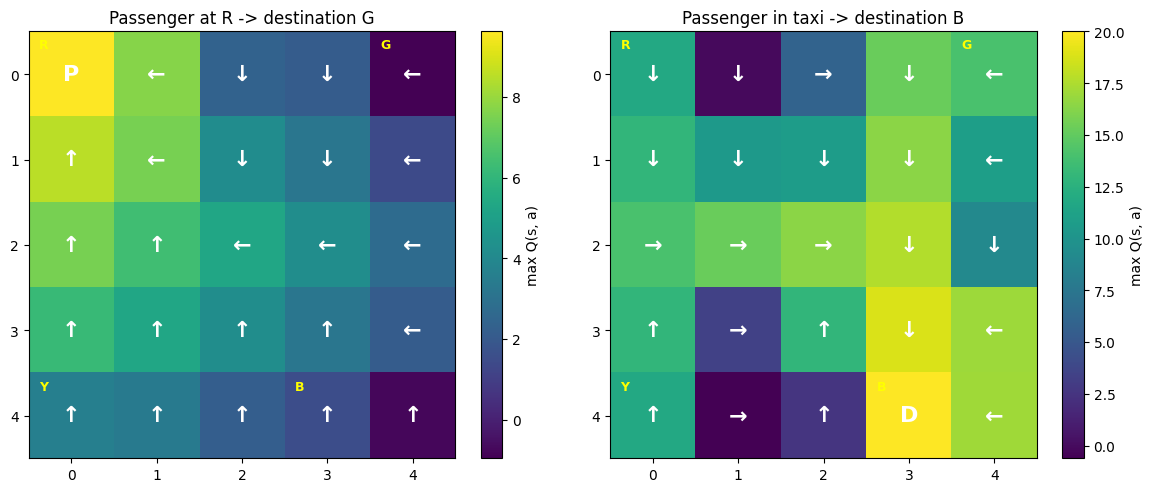

In [5]:
base_env = gym.make("Taxi-v4")
enc = base_env.unwrapped.encode          # (taxi_row, taxi_col, passenger_loc, destination)
arrows = {0: "↓", 1: "↑", 2: "→", 3: "←", 4: "P", 5: "D"}
stops = {"R": (0, 0), "G": (0, 4), "Y": (4, 0), "B": (4, 3)}

def draw(ax, pass_loc, dest, title):
    vals = np.zeros((5, 5)); acts = np.zeros((5, 5), dtype=int)
    for r in range(5):
        for c in range(5):
            s = enc(r, c, pass_loc, dest)
            vals[r, c] = q_table[s].max()
            acts[r, c] = q_table[s].argmax()
    im = ax.imshow(vals, cmap="viridis")
    for r in range(5):
        for c in range(5):
            ax.text(c, r, arrows[acts[r, c]], ha="center", va="center", color="white", fontsize=16, fontweight="bold")
    for name, (r, c) in stops.items():
        ax.text(c - 0.38, r - 0.3, name, color="yellow", fontsize=9, fontweight="bold")
    ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = draw(axes[0], 0, 1, "Passenger at R -> destination G")
im2 = draw(axes[1], 4, 3, "Passenger in taxi -> destination B")
fig.colorbar(im1, ax=axes[0], fraction=0.046, label="max Q(s, a)")
fig.colorbar(im2, ax=axes[1], fraction=0.046, label="max Q(s, a)")
plt.tight_layout(); plt.show()
base_env.close()

## 5. Evaluating the trained (greedy) policy over many episodes
One run is anecdotal, so the greedy policy is tested on 200 random starts.

Success rate : 100.0%
Mean reward  : 7.82
Mean steps   : 13.19


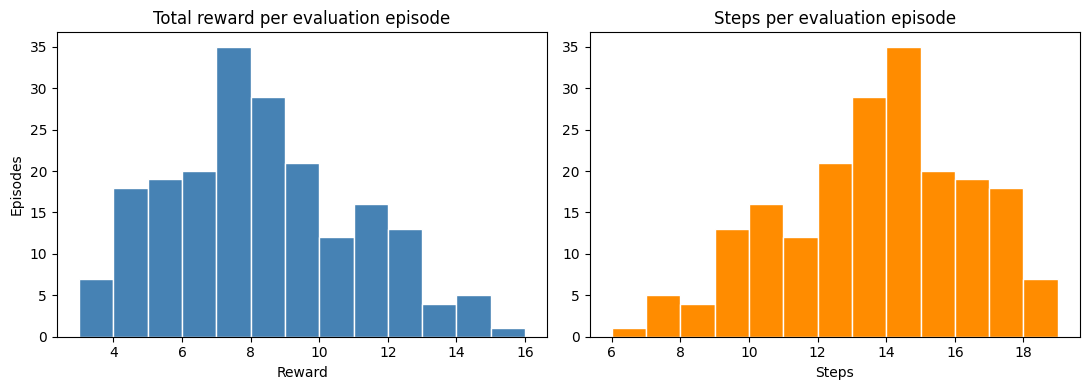

In [6]:
eval_env = gym.make("Taxi-v4")
n_eval = 200
eval_rewards, eval_steps, successes = [], [], 0

for _ in range(n_eval):
    state, info = eval_env.reset()
    done, total, steps = False, 0, 0
    while not done:
        action = np.argmax(q_table[state, :])
        state, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated
        total += reward; steps += 1
    eval_rewards.append(total); eval_steps.append(steps)
    successes += int(terminated)       # terminated = passenger delivered
eval_env.close()

print(f"Success rate : {successes / n_eval:.1%}")
print(f"Mean reward  : {np.mean(eval_rewards):.2f}")
print(f"Mean steps   : {np.mean(eval_steps):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(eval_rewards, bins=range(int(min(eval_rewards)), int(max(eval_rewards)) + 2), color="steelblue", edgecolor="white")
axes[0].set_title("Total reward per evaluation episode"); axes[0].set_xlabel("Reward"); axes[0].set_ylabel("Episodes")
axes[1].hist(eval_steps, bins=range(min(eval_steps), max(eval_steps) + 2), color="darkorange", edgecolor="white")
axes[1].set_title("Steps per evaluation episode"); axes[1].set_xlabel("Steps")
plt.tight_layout(); plt.show()

## 6. Reward composition during training
Share of episodes (per 1000-episode block) that ended with a positive total reward, a rough measure of how quickly the agent learns to deliver passengers.

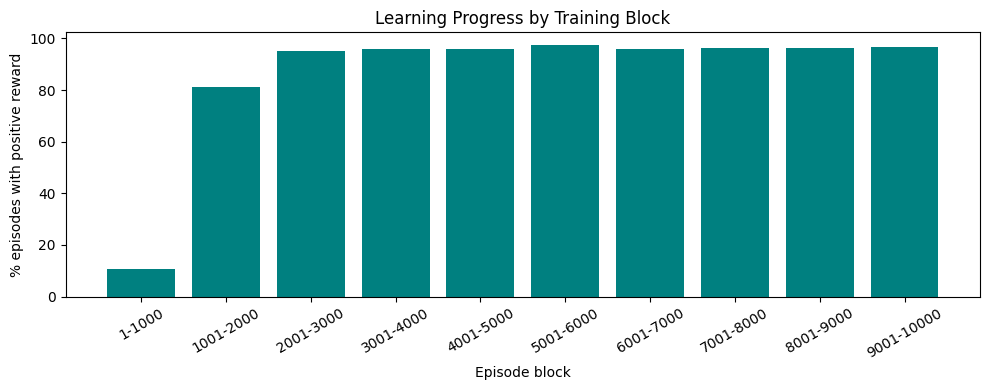

In [7]:
block = 1000
pos_rate = [np.mean(np.array(episode_rewards[i:i+block]) > 0) * 100 for i in range(0, episodes, block)]
labels = [f"{i+1}-{i+block}" for i in range(0, episodes, block)]
plt.figure(figsize=(10, 4))
plt.bar(labels, pos_rate, color="teal")
plt.ylabel("% episodes with positive reward"); plt.xlabel("Episode block")
plt.title("Learning Progress by Training Block"); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 7. Watch the trained agent (animation)
Run this cell locally; it opens a pygame window and then prints a terminal animation.

In [ ]:
# 5. Evaluation / Visualization
# Re-initialize the environment with render mode on so we can see it
env = gym.make("Taxi-v4", render_mode="human")
state, info = env.reset()
done = False

while not done:
    # Now we only exploit our learned Q-table (no more random exploring)
    action = np.argmax(q_table[state, :])
    state, reward, done, truncated, info = env.step(action)
    time.sleep(0.5) # Slow down the loop so you can see it move

env.close()

import os

# 5. Evaluation / Visualization (Terminal Version)
# Change render_mode to "ansi" to output text directly to the console
env = gym.make("Taxi-v4", render_mode="ansi")
state, info = env.reset()
done = False

while not done:
    action = np.argmax(q_table[state, :])
    state, reward, done, truncated, info = env.step(action)
    
    # Clear the terminal screen for a smooth animation effect
    os.system('cls' if os.name == 'nt' else 'clear') 
    
    # Print the text-based map
    print(env.render())
    
    # Show current status
    print(f"Action taken: {action}, Reward: {reward}")
    time.sleep(0.5)

env.close()